# Alfven eigenmode

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pyarrow.feather as feather
import yaml

from labeler.ae.labels import N_BINS, N_FFT
from labeler.ae.transform import frame_times_s, spectrogram
from labeler.config import Paths
from labeler.events.source_formatters import AE_CLASSES
from labeler.events.notebooks import load_shot, plot_shot

In [29]:
shot = 170815
source = "format/shots"
shot_event = load_shot("alfven_eigenmode", shot, source=source)
shot_event["categories"]

{'0': 'absent', '1': 'present'}

### Original labels

In [ ]:
CO2_CHORDS = ("r0", "v1", "v2", "v3")
AE_BAND_LO_KHZ = 50.0
ADJUST_NAME = "co2_250_detector_adjust.pkl"
TS_CACHE = Path("/scratch/gpfs/nc1514/aemodes/data/.cache/ae_timeseries")

In [ ]:
TMIN, TMAX = 0, 2000

event, shot = shot_event["event"], shot_event["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
print(paths)

{'co2_detector_2021': PosixPath('/scratch/gpfs/nc1514/FusionAIHub/data/events/alfven_eigenmode/raw/co2_250_detector.pkl')}


In [33]:
CO2_CHORDS = ("r0", "v1", "v2", "v3")
AE_BAND_LO_KHZ = 50.0
ADJUST_NAME = "co2_250_detector_adjust.pkl"
TS_CACHE = Path("/scratch/gpfs/nc1514/aemodes/data/.cache/ae_timeseries")

def read_co2(shot, cache=TS_CACHE):
    path = next(iter(sorted(Path(cache).glob(f"{int(shot)}_*.arrow"))), None)
    if path is None:
        raise FileNotFoundError(f"no CO2 time series for shot {shot} under {cache}")
    table = feather.read_table(path)
    signals = np.stack([table[c].to_numpy() for c in CO2_CHORDS])
    return signals, table.num_rows / 2.0   # samples per second over 0-2000 ms


def read_ae_labels(path, shot):
    with open(path, "rb") as stream:
        dataset = pickle.load(stream)
    for split, offset in (("train", 0), ("valid", 3)):
        shots, _, labels = dataset[offset : offset + 3]
        for index, candidate in enumerate(shots):
            if int(candidate) == int(shot):
                return split, np.asarray(labels[index])
    raise KeyError(f"shot {shot} is not in {path}")


def read_ae_adjusted(path, shot):
    with open(Path(path).parent / ADJUST_NAME, "rb") as stream:
        adjusted = pickle.load(stream)
    index = int(np.flatnonzero(adjusted["shots"] == int(shot))[0])
    return adjusted["time_ms"], adjusted["label"][index], adjusted["shift_ms"]


def plot_ae(signals, fs, labels, adjusted, *, shot, chords=CO2_CHORDS,
            tmin=TMIN, tmax=TMAX):
    spec = spectrogram(signals)                       # (C, 512, frames)
    t_ms = frame_times_s(signals.shape[1], fs) * 1000.0
    f_khz = np.arange(1, N_BINS + 1) * fs / N_FFT / 1e3   # DC dropped
    vmin, vmax = np.percentile(spec, [50, 99])
    adj_t, adj_label, shift_ms = adjusted
    fig, axes = plt.subplots(
        len(chords) + 2,
        1,
        figsize=(10, 2.0 * len(chords) + 3.0),
        sharex=True,
        height_ratios=[3] * len(chords) + [2, 1],
        layout="constrained",
    )
    for ax, chord, panel in zip(axes, chords, spec):
        ax.imshow(
            panel, origin="lower", aspect="auto", interpolation="nearest",
            extent=(t_ms[0], t_ms[-1], f_khz[0], f_khz[-1]),
            cmap="gist_heat", vmin=vmin, vmax=vmax,
        )
        ax.set_ylim(AE_BAND_LO_KHZ, f_khz[-1])
        ax.set_ylabel(f"{chord}\nkHz")
    ax = axes[-2]
    ax.imshow(
        labels.T, origin="lower", aspect="auto", interpolation="nearest",
        extent=(tmin, tmax, -0.5, len(AE_CLASSES) - 0.5),
        cmap="Blues", vmin=0, vmax=1,
    )
    ax.set(
        yticks=range(len(AE_CLASSES)),
        yticklabels=AE_CLASSES,
        ylabel="Original class",
    )
    ax = axes[-1]
    step = adj_t[1] - adj_t[0]
    ax.imshow(
        adj_label[None, :], origin="lower", aspect="auto", interpolation="nearest",
        extent=(adj_t[0] - step / 2, adj_t[-1] + step / 2, -0.5, 0.5),
        cmap="Blues", vmin=0, vmax=1,
    )
    ax.set(
        yticks=[0],
        yticklabels=["AE"],
        xlabel="Time (ms)",
        ylabel=f"Adjusted",
    )
    ax.set_xlim(t_ms[0], t_ms[-1])
    axes[0].set_title(f"Shot {shot} - CO2 spectrograms from the time series")
    return fig

170815 is a train shot; 1000001 samples at 500 kHz


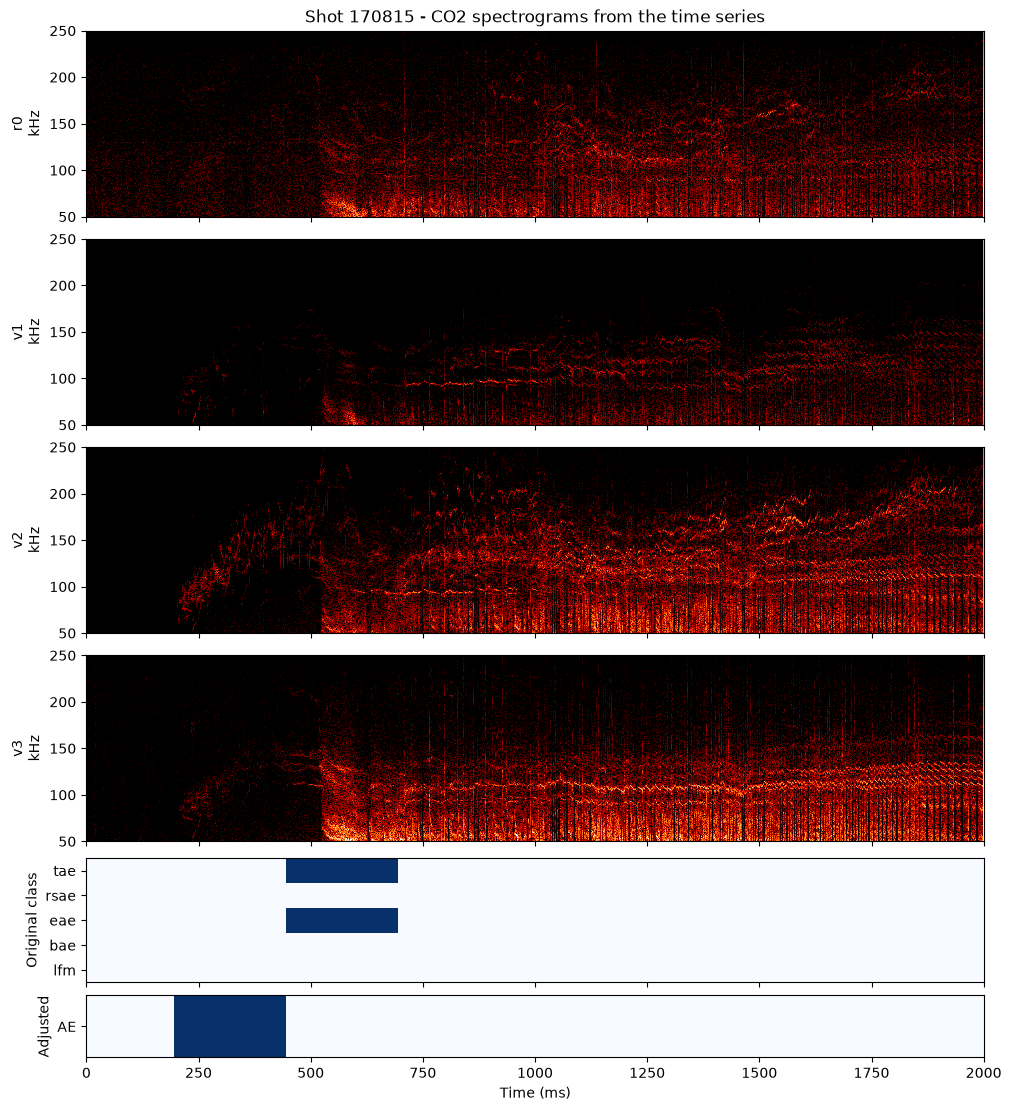

In [34]:
signals, fs = read_co2(shot)
split, labels = read_ae_labels(paths["co2_detector_2021"], shot)
adjusted = read_ae_adjusted(paths["co2_detector_2021"], shot)
print(f"{shot} is a {split} shot; {signals.shape[1]} samples at {fs / 1e3:.0f} kHz")

plot_ae(signals, fs, labels, adjusted, shot=shot)
plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

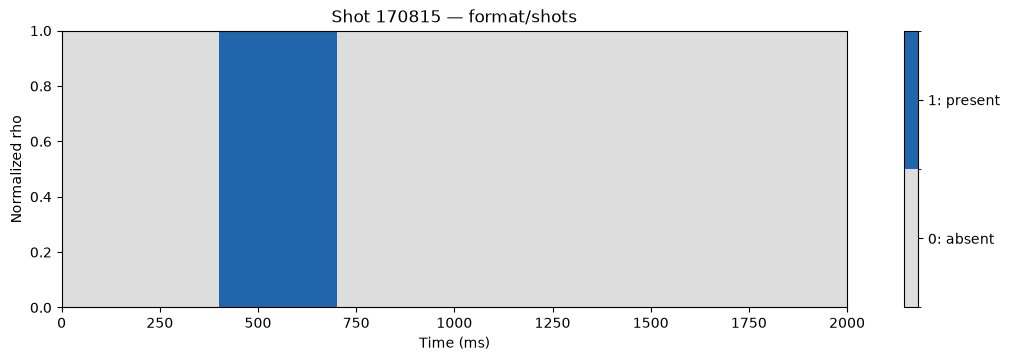

In [26]:
plot_shot(shot_event);

When extended labels are available, set `source` to `extend_<producer>/<shot-list>`.